# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ prepare_model_data (crops to U-Net multiple, no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

### packages

In [5]:
%pip install -e ..

%load_ext autoreload
%autoreload 2

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.2.0-0.editable-py3-none-any.whl size=5715 sha256=b41d730c755cef9eb1a468757cd3eef5bcc128788266bbfe8b3d6bb16bbea358
  Stored in directory: /tmp/pip-ephem-wheel-cache-mm_gku1t/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
  Attempting uninstall: mindthegap
    Found existing installation: mindthegap 0.2.0
    Uninstalling mindthegap-0.2.0:
      Successfully uninstalled mindthegap-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install -qU "icechunk>=2" "earthaccess>=0.15"

In [4]:
!pip install -qU boto3 botocore s3transfer

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.58 requires botocore==1.43.58, but you have botocore 1.43.67 which is incompatible.
aiobotocore 2.25.2 requires botocore<1.40.71,>=1.40.46, but you have botocore 1.43.67 which is incompatible.


## 0. Set-up

`mtg.set_up()` prepares the runtime -- it quiets TensorFlow logging, enables GPU
memory growth, prints the detected device, and returns a fresh `Options`. Pass
`smoke_test=True` for a fast pipeline check (small tiles, few epochs). The
scientific-Python imports (`numpy`, `xarray`, `matplotlib`, ...) stay in the
notebook, since a function cannot inject names into your namespace.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import mindthegap as mtg

# mtg.set_up configures TensorFlow (log level, GPU memory growth), reports the
# device, and returns a fresh Options. Later functions check that options exists.
options = mtg.set_up(smoke_test=False)

E0000 00:00:1786993161.047309   15440 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786993161.053747   15440 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786993161.068131   15440 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786993161.068150   15440 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786993161.068152   15440 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786993161.068154   15440 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


## 1. Load Your Data

Write the dataset-creation code to a standalone `make_dataset.py` with the
`%%writefile` magic, then run it with `%run` so `ds` and the variable names are
loaded into the notebook. Saving the *script* (not just running inline) means
the exact code that built the dataset can be recorded in the model bundle later
(`options` captures everything about training *except* how the raw dataset was
built). Because `%run` executes the file as a standalone program, it must be
self-contained -- include its own imports.

`ds` should be an xarray dataset (lazy if fine) with variables for the target (the variable to be gap-filled), a land flag (1 = land), a missing flag (1 = missing, e.g. clouds), and any extra input variables that you will train on.

In [2]:
%%writefile make_dataset.py
# make_dataset.py -- builds the raw dataset and nothing else. mtg.demo_data
# loads a dataset, records its identity/source on ds.attrs, prints its
# dimensions, and returns the ds plus the names of its target, missing (cloud)
# flag, and land flag variables. This file is recorded verbatim in the model
# bundle (as make_dataset.py) so the dataset build is reproducible.
#
# Examples of other datasets you could load with mtg.demo_data():
#   dataset = "globcolour";   region = "arabian sea";   time_slice = None
#   dataset = "indian-ocean"; region = "indian ocean"; time_slice = slice("01-01-2000", "12-31-2000")
import mindthegap as mtg

dataset = "io-shared-public"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"       # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2010", "01-01-2020")

# target is the variable name of the variable being gap-filled; _flag are the names of the flags in the dataset.
ds, target, missing_flag, land_flag = mtg.demo_data(
    dataset,
    region=region,
    time_slice=time_slice,
    smoke_test=False,
)

Writing make_dataset.py


In [3]:
# Run the script we just wrote. %run executes it in the notebook namespace, so
# ds, target, missing_flag, and land_flag are defined for the cells below.
%run make_dataset.py
ds

Dataset: IO rechunkded in shared-public
  target:       CHL_cmes-level3
  missing_flag: CHL_cmes-cloud
  land_flag:    CHL_cmes-land
  dimensions:   {'time': 3653, 'lat': 169, 'lon': 241}


<xarray.Dataset> Size: 3GB
Dimensions:          (time: 3653, lat: 169, lon: 241)
Coordinates:
  * time             (time) datetime64[ns] 29kB 2010-01-01 ... 2020-01-01
  * lat              (lat) float32 676B 30.0 29.75 29.5 ... -11.5 -11.75 -12.0
  * lon              (lon) float32 964B 42.0 42.25 42.5 ... 101.5 101.8 102.0
Data variables:
    air_temp         (time, lat, lon) float32 595MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    CHL_cmes-cloud   (time, lat, lon) uint8 149MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    CHL_cmes-level3  (time, lat, lon) float32 595MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    sst              (time, lat, lon) float32 595MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    u_wind           (time, lat, lon) float32 595MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    v_wind           (time, lat, lon) float32 595MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
    CHL_cmes-land    (time, lat, lon) int8 149MB dask.array<chunksize=(55, 32, 56), meta=np.ndarray>
Attributes: (12/97)
    Conventions:                     CF-1.8, ACDD-1.3
    DPM_reference:                   GC-UD-ACRI-PUG
    IODD_reference:                  GC-UD-ACRI-PUG
    acknowledgement:                 The Licensees will ensure that original ...
    citation:                        The Licensees will ensure that original ...
    cmems_product_id:                OCEANCOLOUR_GLO_BGC_L3_MY_009_103
    ...                              ...
    westernmost_valid_longitude:     -180.0
    dataset_name:                    IO rechunkded in shared-public
    dataset_source:                  /home/jovyan/shared-public/mindthegap/da...
    product_id:                      shared-public/IO_rechunked.zarr
    region_name:                     indian ocean
    data_source:                     demo_data(dataset='io-shared-public', re...

## Set up options

### Required data options

* `target` name of the variable in `ds` that you are trying to gapfill
* `missing_flag` name of the variable that designates the missing pixels you are trying to fill. For example, `cloud_mask`. 1 = missing pixel.
* `land_flag` these are pixels that are not estimated, but whose boundaries affect estimates. For example, land. Set to all 0 if this is not relevant for your application.
* `log_target` whether to log the target. For example, chlorophyll is 0 bounded and should be logged.

The method `options.set_up_data_options()` is a helper to set the needed `options.data` elements. You can set these manually also.

In [4]:
# Reads the dataset identity/bounds from ds (and its attrs). target,
# missing_flag, and land_flag are required; the rest are optional.
#
# Synthetic-cloud settings are grouped: cloud_mode (default "synthetic_bank",
# not required) selects the cloud source, and cloud_options is a dict of only
# the parameters that apply to that mode:
#   synthetic_bank / synthetic: cloud_coverage, cloud_blob_sigma, cloud_time_sigma
#   shift:                      missing_flag_shift
# (cloud_seed applies to any mode). mtg.cloud_options_for(mode) lists the valid
# keys; passing a key that does not apply to the chosen mode raises an error.
options.set_up_data_options(
    ds,
    target=target,
    missing_flag=missing_flag,
    land_flag=land_flag,
    log_target=True,
    # cloud_mode="synthetic_bank",  # the default
    # cloud_options={"cloud_coverage": 0.4, "cloud_blob_sigma": 6.0},
);

### Optional settings

If you want to customize the training data, do that with `set_up_train_split_options()`. You can also customize the xbatcher tile size with `set_up_gridder_options()`.

**`set_up_train_split_options()`** `split_mode` selects the strategy (default
 "random") and `split_options` is a dict of the parameters that apply to it.
 The default is a random split over ALL days in ds. use `split_options={"n_days": 500}` to 
 limit to a fixed number of days.

In [9]:
mtg.set_up_train_split_options(ds, options, split_mode="random", split_options={"n_days": 500});

Split method: random (train=400, val=100 dates)
Training period: 2010-01-03 to 2019-12-27


In [ ]:
# Optional: recommend a memory-aware gridder (tile size, dask time chunk, batch
# size). Mirrors set_up_data_options: tunables go in a gridder_options dict, e.g.
# gridder_options={"gpu_memory_gb": 16, "min_tile": 64}. Generally run this AFTER
# set_up_train_split_options: when options.split.n_days is set the recommended
# time chunk targets that many days (capped to fit in RAM). apply=None prompts
# before writing to options; apply=True/False applies/returns only.
mtg.set_up_gridder_options(ds, options)

## 2. Build Standardized Training data

Use `prepare_model_data()` to create standardized predictors **without loading data into memory**. It crops the spatial dimensions to a U-Net-compatible multiple internally.

* chose train/validation dates
* add n-prev and n-next targets as inputs
* add features (optional) as inputs; standardize
* add flags (land, real cloud, fake cloud)
* rename the target; standardize and log (optional)

In [ ]:
# prepare_model_data resolves the train/validation split automatically when it
# is unset (mode="train" only), running mtg.set_up_train_split_options(ds, options).
# Call set_up_train_split_options yourself first if you want to inspect/override it.
ds_std = mtg.prepare_model_data(ds, options, mode="train")
ds_std.load()

## Copilot: Ignore this section

Problem with the IO data. Note for developers.

There is a gap between land and where the measurements start. That should be fixed.

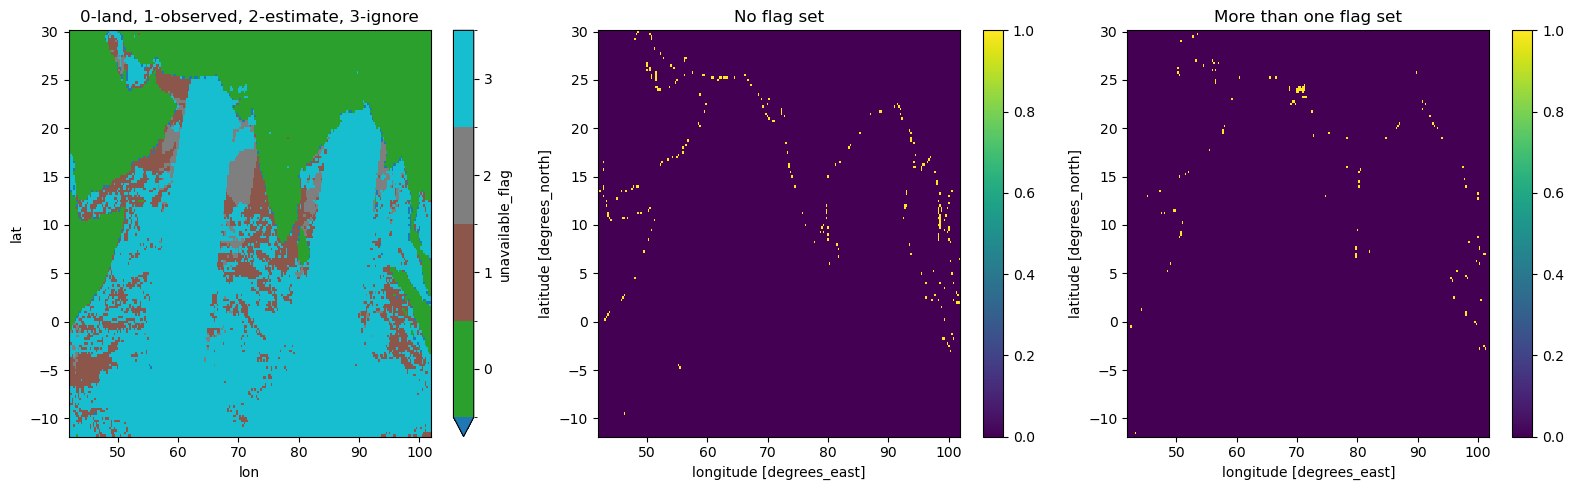

In [16]:
import matplotlib.pyplot as plt
import xarray as xr

t = 20

land = ds_std.land_flag.isel(time=t)
observed = ds_std.observed_flag.isel(time=t)
estimate = ds_std.estimate_flag.isel(time=t)
unavailable = ds_std.unavailable_flag.isel(time=t)

# Count how many flags are set at each pixel
flag_count = land + observed + estimate + unavailable

# Category map:
# 0 = land
# 1 = observed
# 2 = estimate
# 3 = unavailable
category = xr.full_like(land, fill_value=-1, dtype="int8")
category = xr.where(land == 1, 0, category)
category = xr.where(observed == 1, 1, category)
category = xr.where(estimate == 1, 2, category)
category = xr.where(unavailable == 1, 3, category)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

category.plot(
    ax=axes[0],
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap="tab10",
    cbar_kwargs={"ticks": [0, 1, 2, 3]},
)
axes[0].set_title("0-land, 1-observed, 2-estimate, 3-ignore")

(flag_count == 0).plot(ax=axes[1])
axes[1].set_title("No flag set")

(flag_count > 1).plot(ax=axes[2])
axes[2].set_title("More than one flag set")

plt.tight_layout()

In [22]:
land = ds_std.land_flag.isel(time=t).astype("int8").compute()
observed = ds_std.observed_flag.isel(time=t).astype("int8").compute()
estimate = ds_std.estimate_flag.isel(time=t).astype("int8").compute()
unavailable = ds_std.unavailable_flag.isel(time=t).astype("int8").compute()

flag_count = land + observed + estimate + unavailable

combo = (
    1 * land
    + 2 * observed
    + 4 * estimate
    + 8 * unavailable
)

vals, counts = np.unique(
    combo.where(flag_count > 1).values,
    return_counts=True,
)

names = {
    3: "land + observed",
    5: "land + estimate",
    6: "observed + estimate",
    7: "land + observed + estimate",
    9: "land + unavailable",
    10: "observed + unavailable",
    11: "land + observed + unavailable",
    12: "estimate + unavailable",
    13: "land + estimate + unavailable",
    14: "observed + estimate + unavailable",
    15: "all four",
}

for v, n in zip(vals, counts):
    if not np.isnan(v):
        print(f"{names[int(v)]:35s} {n}")

land + observed                     51
land + unavailable                  69


## 3. Train the Model

`mtg.train_model()` runs the full pipeline: `prepare_model_data`, the xbatcher streaming tiler, the fully-convolutional `mtg.UNet`, and the fit loop configured by `options`. It returns a `TrainingResult`.

In [ ]:
# The streaming train/validation pipeline (xbatcher tiling + tf.data) is built
# inside mtg.train_model below, so there is no separate make_generator step
# here. To build the datasets by hand instead, call
# mtg.make_generator(ds_std, options) directly.

The channel count, U-Net architecture, and fit configuration are all taken from the resolved `options`, so the bundle and the fitting pipeline cannot diverge.

In [ ]:
# mtg.train_model builds the fully-convolutional mtg.UNet for you from the
# resolved channel count. To build it by hand instead, call
# mtg.UNet((None, None, len(options.data.input_names)), tile_size=...).

Train with bounded memory: data is streamed one tile at a time.

In [6]:
# Train the model end to end. mtg.train_model runs prepare_model_data, sets up
# the xbatcher streaming pipeline, builds mtg.UNet, and fits it with options.fit
# (optimizer, learning rate, loss, EarlyStopping). It returns a TrainingResult:
#   result.model    - the fitted model
#   result.options  - the resolved configuration (single source of truth)
#   result.metrics  - final validation metrics (val_loss, val_mae)
#   result.history  - epoch-by-epoch training history (dict of lists)
#   result.metadata - resolved run provenance (package version, device, ...)
result = mtg.train_model(ds, options, load_data=True)

model = result.model
history = result.history
print(result.summary())

Split method: random (train=400, val=100 dates)
Training period: 2010-01-10 to 2019-12-22
Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (98, 98, 98, 98, 108), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})
Streaming datasets ready (batch size 16): steps per epoch train=150, val=37

Model input shape: (batch, 64, 64, 9)
Model output shape: (batch, 64, 64, 1)

Input names: ['observed_target', 'observed_target_m1', 'observed_target_p1', 'day_sin', 'day_cos', 'estimate_flag', 'unavailable_flag', 'observed_flag', 'land_flag']
Starting training: epochs=50, batch_size=16, patience=10
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - loss: 0.0936 - mae: 0.1601 - val_loss: 0.0421 - val_mae: 0.1046
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 90m

## 6. Visualize Training History

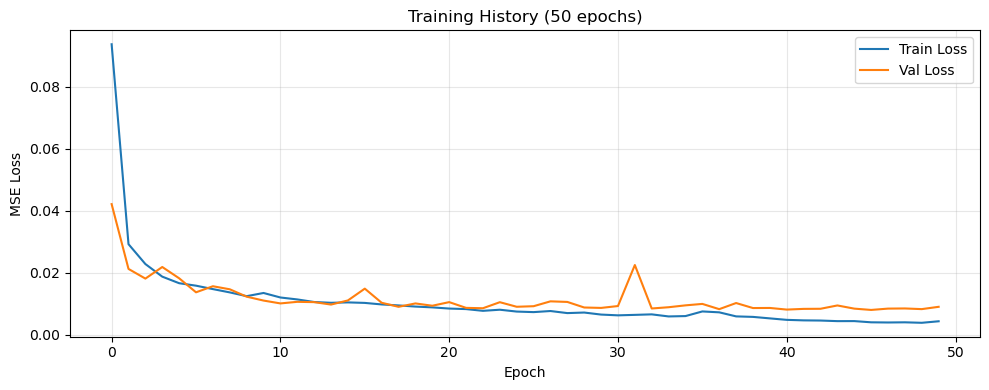


Best epoch: 46
Best val_loss: 0.007992


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history['loss'])
ax.plot(history['loss'], label='Train Loss')
ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history['val_loss']) + 1}")
print(f"Best val_loss: {min(history['val_loss']):.6f}")

## 7. Make a prediction

Load one test frame and predict on the full domain to verify the model works.

When training, the target is 0 under clouds (nan replaced with 0). So the model learns that if there is a real cloud (real_cloud_flag is 1) then predict 0 always. The model also learns that if estimate_flag = 0 and unavailable_flag = 0, then there is a value in the observed_target input and use that. If estimate_flag = 1 and unavailable_flag = 0, then there is always a 0 in observed_target (non-informative) so make an estimate from the other input variables. 

That means if we make a prediction from ds_test, it will have 0s whereever there are real clouds and it will only make estimates under the synthetic clouds.

Test prediction date: 2020-01-01
Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 53), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


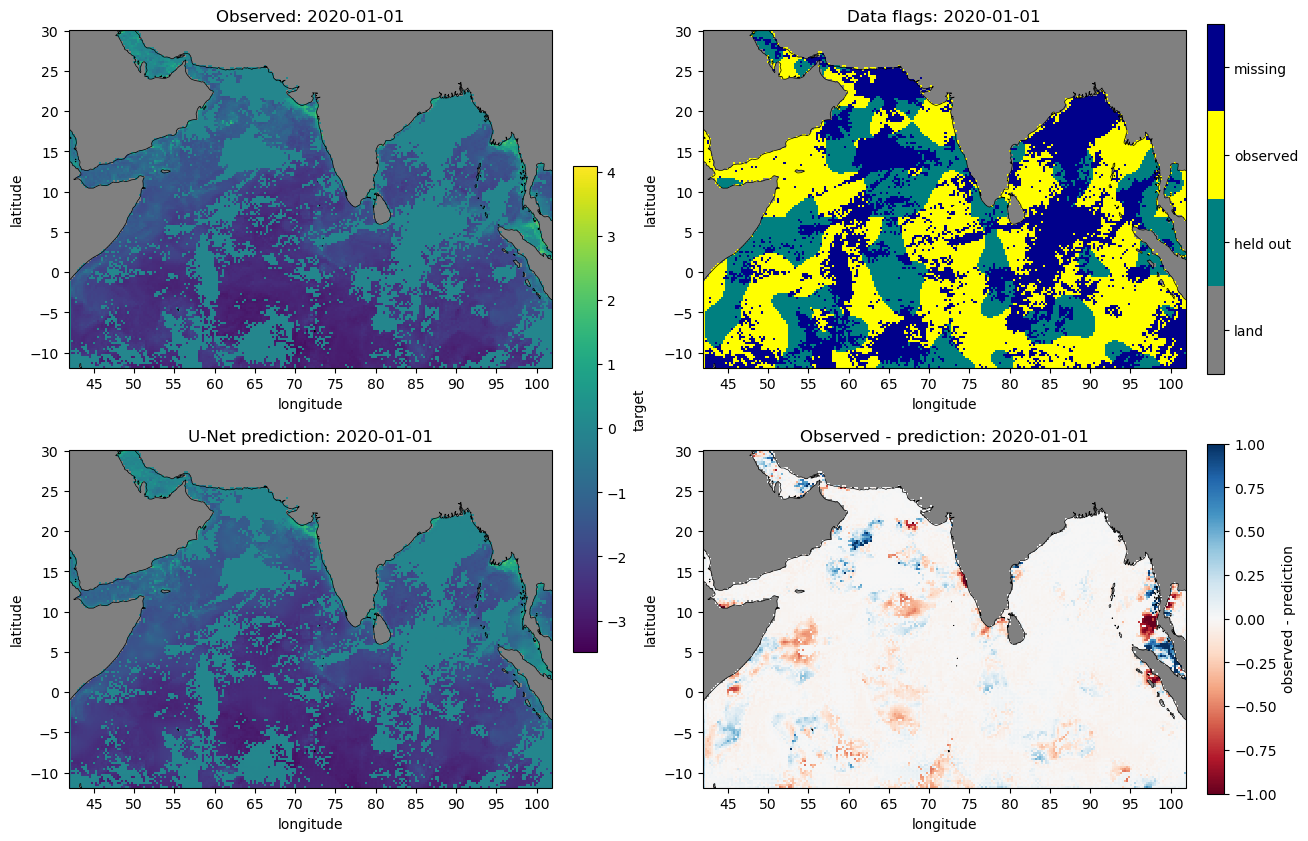

In [37]:
from mindthegap import viz

# Pick a test day: the last date in the record that was not used for training
# or validation, falling back to the final available day.
used = set(options.split.train_dates) | set(options.split.val_dates)
available = [str(pd.to_datetime(t).date()) for t in ds.time.values]
unused = [d for d in available if d not in used]
test_date = unused[-1] if unused else available[-1]
print(f"Test prediction date: {test_date}")

# Select test frame
ds_std = mtg.prepare_model_data(ds, options, mode="test")
ds_std["full_target"] = ds_std["full_target"].fillna(0)

fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    options,
    test_date,
    difference_limit=1.0,
)
plt.show()

## 8. Save Model

Save the trained model for later use.

In [ ]:
# Everything the bundle needs is already resolved on options.data, so the
# bundle and the fitting pipeline cannot diverge. save_model_bundle takes the
# TrainingResult from mtg.train_model and writes model.keras, options.json (the
# single source of truth for how the model was set up), metrics.json (the run's
# metrics/metadata/history for experiment tracking), and README.md. The one
# thing options does not capture is how the raw dataset was built, so record the
# make_dataset.py we wrote above via dataset_script; its contents are copied
# verbatim into the bundle's make_dataset.py.
from pathlib import Path

bundle_path = Path("../models") / f"{dataset}-unet-bundle"
mtg.save_model_bundle(
    result,
    bundle_path,
    limitations=(
        "Validated only for the documented product, region, training period, "
        "channel order, and preprocessing configuration."
    ),
    dataset_script="make_dataset.py",
    overwrite=True,
)
print(f"✓ Model bundle saved to: {bundle_path}")

### Review the saved bundle

The bundle directory now contains `model.keras`, `options.json`, and a `README.md` model card. Open `README.md` and `options.json` and confirm the dataset, region, training period, input channel order, transforms, and standardization values. `options.json` is the single source of truth used to reload and replay the model.

In [36]:
# Verify that the released artifact loads without rebuilding the U-Net.
loaded_model, loaded_options = mtg.load_model_bundle(bundle_path)
round_trip_input = X_test[:1]
expected = model(round_trip_input, training=False).numpy()
actual = loaded_model(round_trip_input, training=False).numpy()
np.testing.assert_allclose(actual, expected, rtol=1e-6, atol=1e-6)
assert loaded_options.data.input_names == options.data.input_names
print("✓ Bundle reload produced equivalent predictions")

Data loaded for this model with: demo_data(dataset='io-shared-public', region='indian ocean', time_slice=slice('01-01-2010', '01-01-2020'))
✓ Bundle reload produced equivalent predictions
